In [1]:
"""
Generate steady-state solutions for the 2D Poisson' equation.
"""

import os
import sys
import json

# Add directory containing dd_nm_rom to PYTHONPATH
module_path = "/home/pinghsuan/Research/DD-NM-ROM"
os.environ["PYTHONPATH"] = module_path + ":" + os.environ.get("PYTHONPATH", "")

# Inputs
# =====================================
inpfile = '../inputs/test_dd_nmrom.json'

with open(inpfile) as file:
  inputs = json.load(file)

# Import 'dd_nm_rom' package
# =====================================
with open(inputs["pathfile"]) as file:
  paths = file.read().splitlines()
sys.path.extend(paths)

# Environment
# =====================================
from dd_nm_rom import env
env.set(**inputs["env"])

# Libraries
# =====================================
import shutil
import numpy as np
import dill as pickle

from tqdm import tqdm
from dd_nm_rom import ops
from dd_nm_rom import utils
from dd_nm_rom import postproc
from dd_nm_rom import fom as fom_mod
from dd_nm_rom import rom as rom_mod
from dd_nm_rom import field as field_mod
from dd_nm_rom.rom.utils import pod as pod_mod
from dd_nm_rom.elements import mesh as mesh_mod


import matplotlib.pyplot as plt
from matplotlib import cm
from dd_nm_rom.postproc import plot_field


In [2]:
# Initialization
# =====================================
print("\nInitialization ...")
# Mesh
mesh = utils.get_class(modules=[mesh_mod], **inputs["mesh"])
mesh.build()
X, Y = mesh.grid

# Field
field = utils.get_class(
  modules=[field_mod],
  name=inputs["field"]["name"]
)(mesh=mesh, **inputs["field"]["kwargs"])
field.set_params(mu=field.sample_design_space())

# FOM
fom = utils.get_class(
  modules=[fom_mod],
  name="Poisson2D"
)(mesh=mesh, **inputs["fom"]["kwargs"])
force = field.get_force()
fom.build(field, force=force)

dd_fom = utils.get_class(
  modules=[fom_mod],
  name="DDPoisson2D"
)(monolithic=fom, **inputs["dd_fom"]["kwargs"])
dd_fom.build()
dd_fom.get_force(force)


Initialization ...
False
False
20000
(1, 20000)


array([0.55638499, 0.92486822, 1.28970142, ..., 0.        , 0.        ,
       0.        ])

In [3]:
# Data loading
# =====================================
print("\nLoading training cases ...")
train_cases = utils.load_case_parallel(**inputs["data_load"])
train_cases = [case for case in train_cases if case is not None]


Loading training cases ...
> Cases: 100%|██████████████████████████████████| 20/20 [00:00<00:00, 41.13it/s]


> Train cases:   0%|                                     | 0/20 [00:00<?, ?it/s]

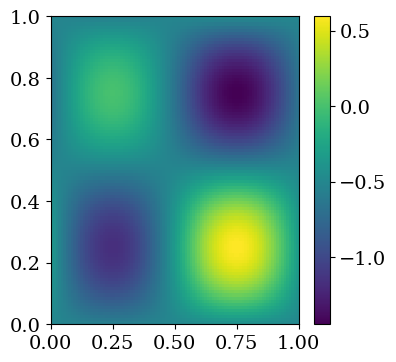

> Train cases:   5%|█▍                           | 1/20 [00:00<00:07,  2.52it/s]

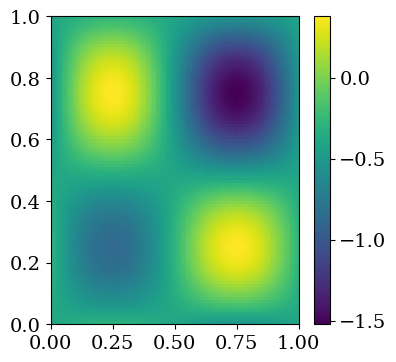

> Train cases:  10%|██▉                          | 2/20 [00:00<00:07,  2.56it/s]

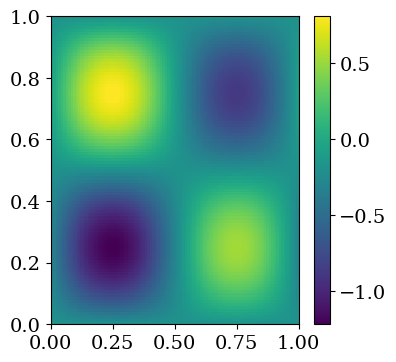

> Train cases:  15%|████▎                        | 3/20 [00:01<00:06,  2.68it/s]

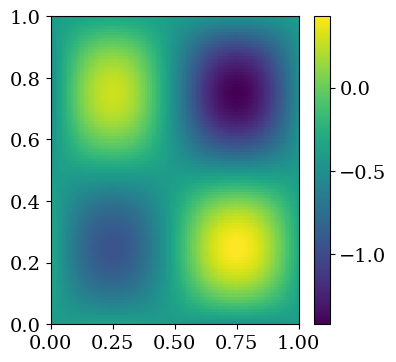

> Train cases:  20%|█████▊                       | 4/20 [00:01<00:05,  2.76it/s]

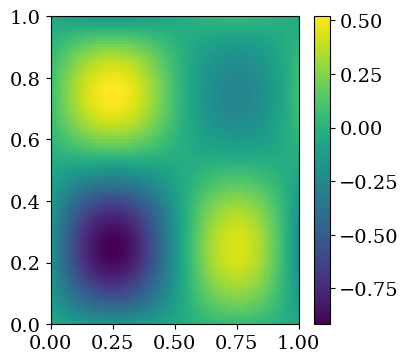

> Train cases:  25%|███████▎                     | 5/20 [00:02<00:07,  2.08it/s]

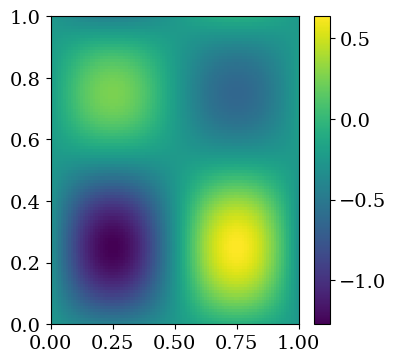

> Train cases:  30%|████████▋                    | 6/20 [00:02<00:06,  2.30it/s]

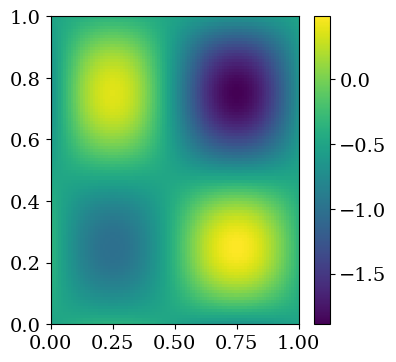

> Train cases:  35%|██████████▏                  | 7/20 [00:02<00:05,  2.37it/s]

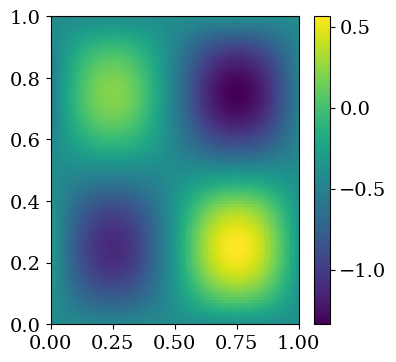

> Train cases:  40%|███████████▌                 | 8/20 [00:03<00:04,  2.49it/s]

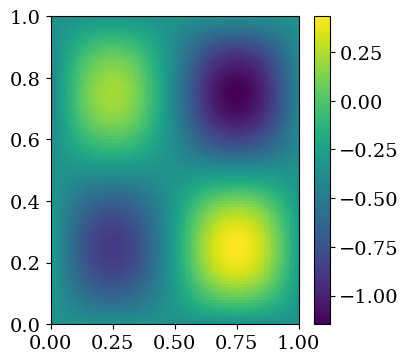

> Train cases:  45%|█████████████                | 9/20 [00:03<00:04,  2.55it/s]

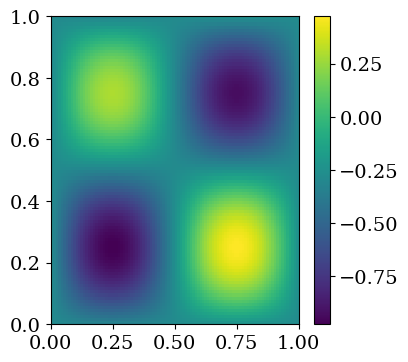

> Train cases:  50%|██████████████              | 10/20 [00:04<00:03,  2.60it/s]

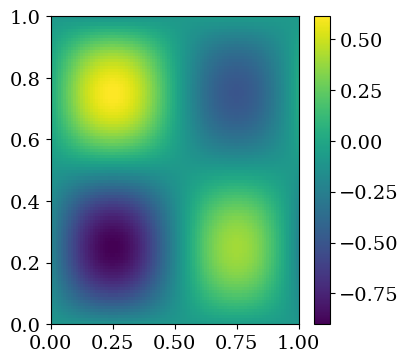

> Train cases:  55%|███████████████▍            | 11/20 [00:04<00:03,  2.49it/s]

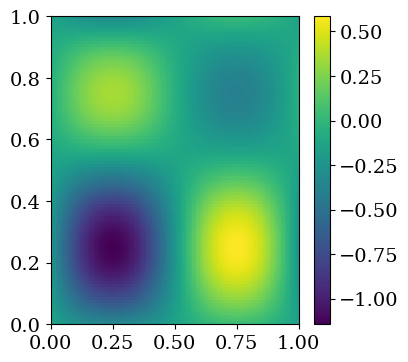

> Train cases:  60%|████████████████▊           | 12/20 [00:04<00:03,  2.48it/s]

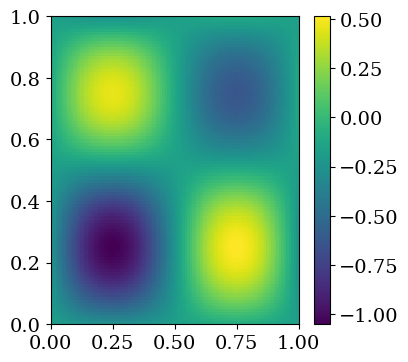

> Train cases:  65%|██████████████████▏         | 13/20 [00:05<00:02,  2.51it/s]

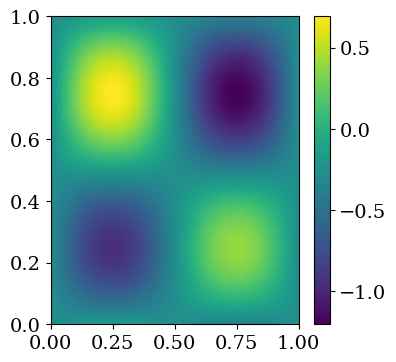

> Train cases:  70%|███████████████████▌        | 14/20 [00:05<00:02,  2.60it/s]

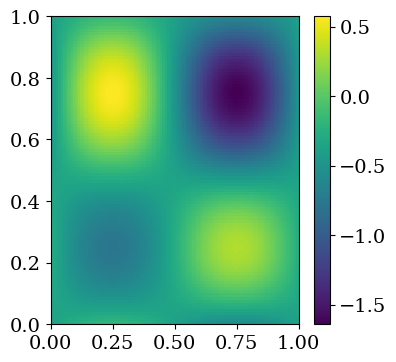

> Train cases:  75%|█████████████████████       | 15/20 [00:05<00:01,  2.66it/s]

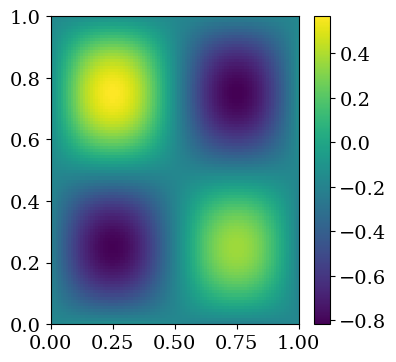

> Train cases:  80%|██████████████████████▍     | 16/20 [00:06<00:01,  2.82it/s]

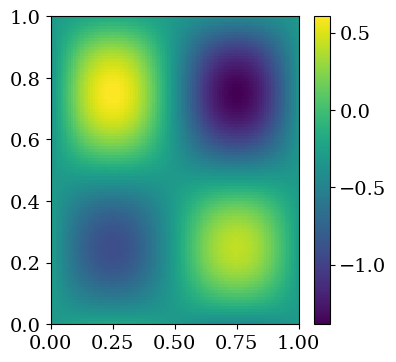

> Train cases:  85%|███████████████████████▊    | 17/20 [00:06<00:01,  2.97it/s]

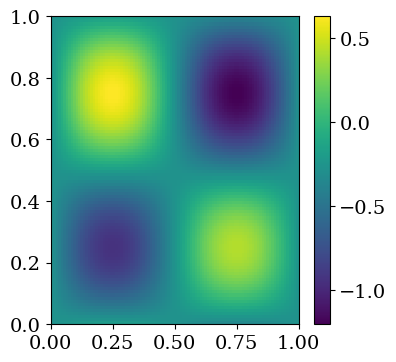

> Train cases:  90%|█████████████████████████▏  | 18/20 [00:06<00:00,  3.12it/s]

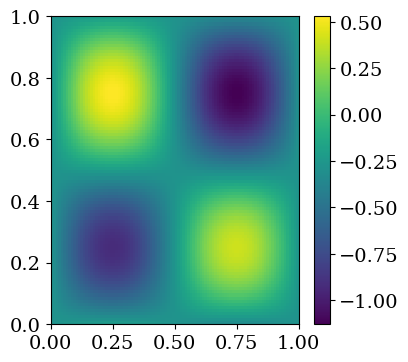

> Train cases:  95%|██████████████████████████▌ | 19/20 [00:07<00:00,  2.98it/s]

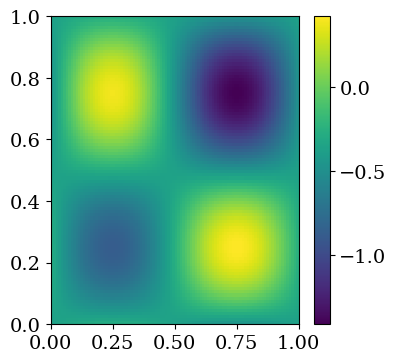

> Train cases: 100%|████████████████████████████| 20/20 [00:07<00:00,  2.64it/s]


In [4]:
import random

for icase in tqdm(train_cases, desc="> Train cases", ncols=80, file=sys.stdout):
    uv = {}
#   rand_int = random.randint(0, 100)
    rand_int=0
    uv['u'], uv['v'] = icase['snapshots'][rand_int, :fom.mesh.nxy], icase['snapshots'][rand_int,  fom.mesh.nxy:]
    U = uv["u"].reshape(fom.mesh.n['y'], fom.mesh.n['x'])
    V = uv["v"].reshape(fom.mesh.n['y'], fom.mesh.n['x'])
    plot_kwargs = dict(
    x=X,
    y=Y,
    lim=None,
    figsize=(4, 4),
    save=True,
    show=True,
    show_labels=False
    )
    plt.rcParams.update({'font.size': 14})
    plot_field(
    z=U,
    label="$u$",
    filename=f"./training_data/poisson/case_{str(icase['index']+1).zfill(5)}.png",
    **plot_kwargs
    )
    

In [5]:

# Data generation
# =====================================
# Solution function
# -------------------------------------
def compute_sol(index):
  mu_i = mu[index]
  # Set current parameters
  field.set_params(mu_i)
  force = field.get_force()
  fom.build(field, force=force)
  # Solve PDE
  uv, res, converged = fom.solve(**inputs["solver"])
  # Save solution
  if converged:
    case_i = {
      "index": index,
      "mu": mu_i,
      "snapshots": np.concatenate([uv["u"], uv["v"]]),
      "residuals": res,
      "runtime": fom.runtime
    }
    utils.save_case(path=path_to_save, index=index, data=case_i)
  return int(converged)


In [6]:
mu_i = mu[99]
# Set current parameter1
field.set_params(mu_i)
force = field.get_force()
fom.build(field, force=force)

False
False


In [ ]:
f = {}
f['u'], f['v'] = force[:fom.mesh.nxy], force[fom.mesh.nxy:]
Fu = f["u"].reshape(fom.mesh.n['y'], fom.mesh.n['x'])
Fv = f["v"].reshape(fom.mesh.n['y'], fom.mesh.n['x'])

In [8]:
mesh_mono = mesh_mod.MeshMono(
  nx=100,
  ny=100,
  x_lim=[0.0, 1.0],
  y_lim=[0.0, 1.0]
)
mesh_mono.build()
X, Y = mesh_mono.grid

In [9]:

import matplotlib.pyplot as plt
from matplotlib import cm
from dd_nm_rom.postproc import plot_field

[0.91497391 0.87100294 0.80263322 0.75866225 6.         6.        ]


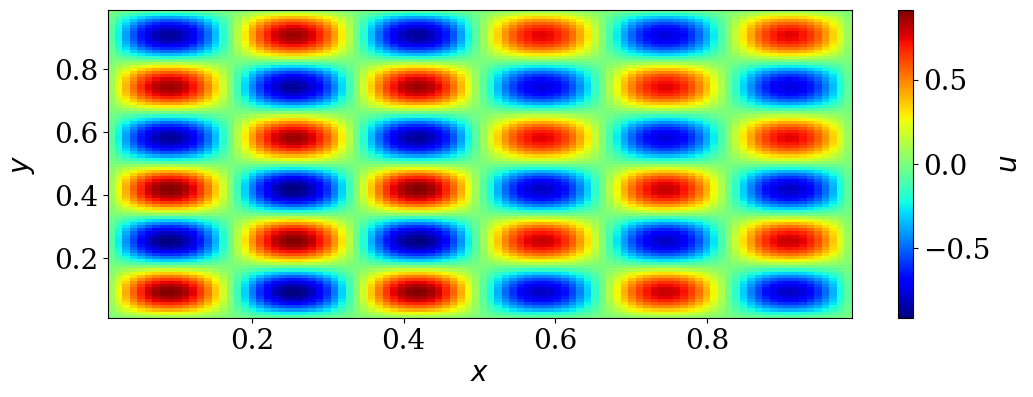

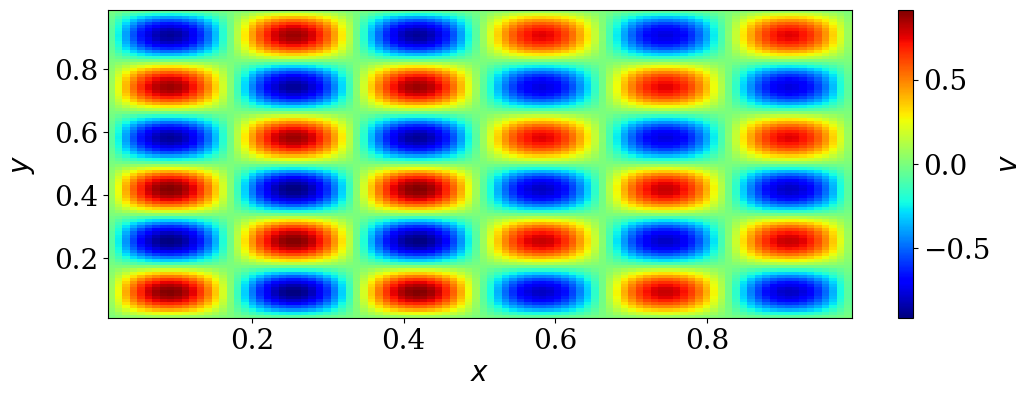

In [10]:
plot_kwargs = dict(
  x=X,
  y=Y,
  lim=None,
  figsize=(12, 4),
  cmap=cm.jet,
  save=True,
  show=True
)
print(mu_i)
plot_field(
  z=Fu,
  label="$u$",
  filename="./fu.png",
  **plot_kwargs
)
plot_field(
  z=Fv,
  label="$v$",
  filename="./fv.png",
  **plot_kwargs
)

In [11]:
uv, res, converged = fom.solve(**inputs["solver"])
# Save solution
#if converged:
#    case_i = {
#      "index": index,
#      "mu": mu_i,
#      "snapshots": np.concatenate([uv["u"], uv["v"]]),
#      "residuals": res,
#      "runtime": fom.runtime
#    }
#utils.save_case(path=path_to_save, index=index, data=case_i)

Time step    1/1
|   Iteration |    Stepsize |    Residual |
| ----------- | ----------- | ----------- |
|           0 |  0.0000e+00 |  5.9325e+01 |
|           1 |  1.0000e+00 |  6.3270e-13 |
Solver terminated after 1 iterations with residual norm of 6.3270e-13.
Execution time: 1.90320e-01 s


[1.46070042 1.32160468 0.76613966 0.62704391 4.         6.        ]


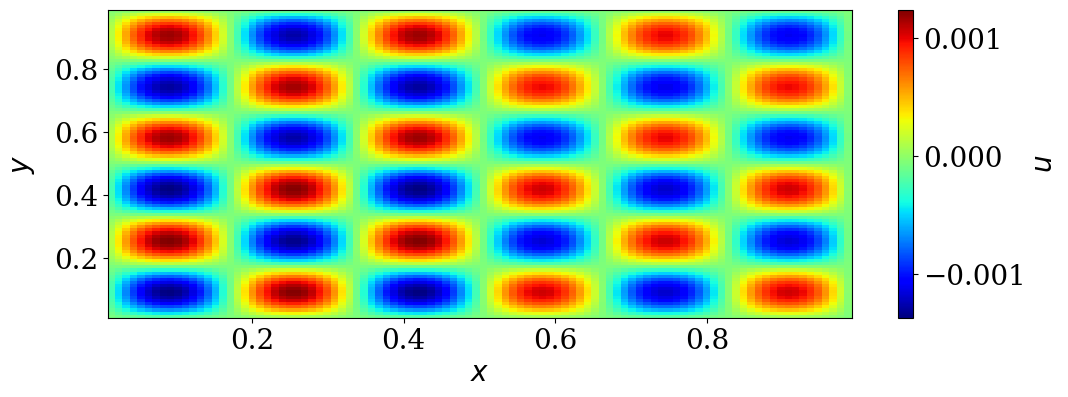

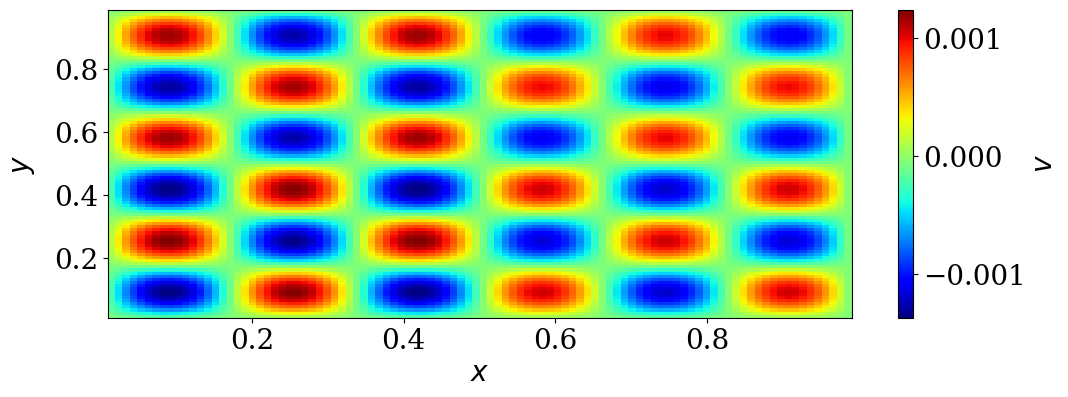

In [13]:
U = uv["u"].reshape(fom.mesh.n['y'], fom.mesh.n['x'])
V = uv["v"].reshape(fom.mesh.n['y'], fom.mesh.n['x'])
print(mu[0])
plot_field(
  z=U,
  label="$u$",
  filename="./u.png",
  **plot_kwargs
)
plot_field(
  z=V,
  label="$v$",
  filename="./v.png",
  **plot_kwargs
)

In [13]:

# Parallel data generation
# -------------------------------------
print("\nData generation ...")
utils.generate_case_parallel(compute_sol, **inputs["data_gen"])
# Save parameters
filename = path_to_save + "/mu.p"
pickle.dump(mu, open(filename, "wb"))
# Copy input file
filename = path_to_save + "/inputs.json"
shutil.copyfile(inpfile, filename)
print("\nDone!\n")


Data generation ...
> Cases:  32%|██████████▌                      | 32/100 [00:00<00:00, 71.96it/s]True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
> Cases:  64%|█████████████████████            | 64/100 [00:02<00:01, 26.88it/s]True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
TrueTrue

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
> Cases: 100%|████████████████████████████████| 100/100 [00:02<00:00, 37.83it/s]
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
Tru

In [12]:
# > Use DD-FOM
dd_fom.build()
dd_fom.get_force(force)
uv, *_, converged = dd_fom.solve(**inputs["solver"])

Time step    1/1
|   Iteration |    Stepsize |    Residual |
| ----------- | ----------- | ----------- |
|           0 |  0.0000e+00 |  5.1903e+00 |
|           1 |  1.0000e+00 |  8.1389e-12 |
Solver terminated after 1 iterations with residual norm of 8.1389e-12.
Execution time: 9.21322e-01 s


[1.46070042 1.32160468 0.76613966 0.62704391 4.         6.        ]


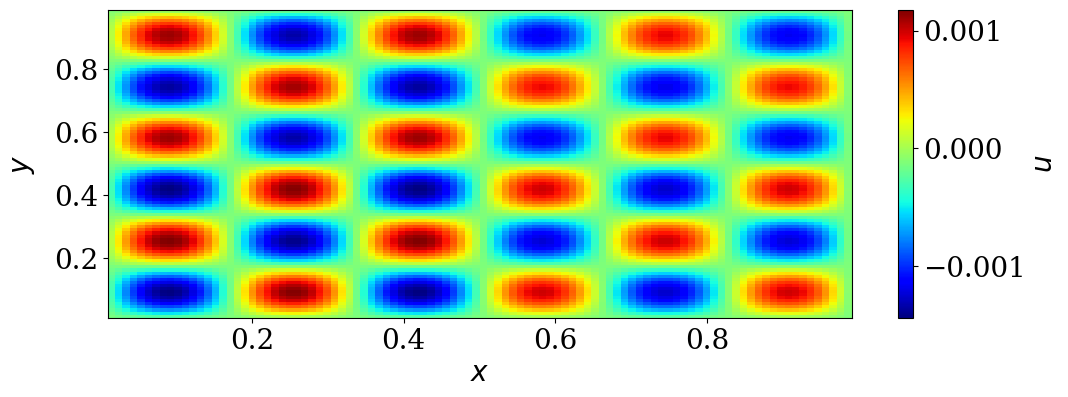

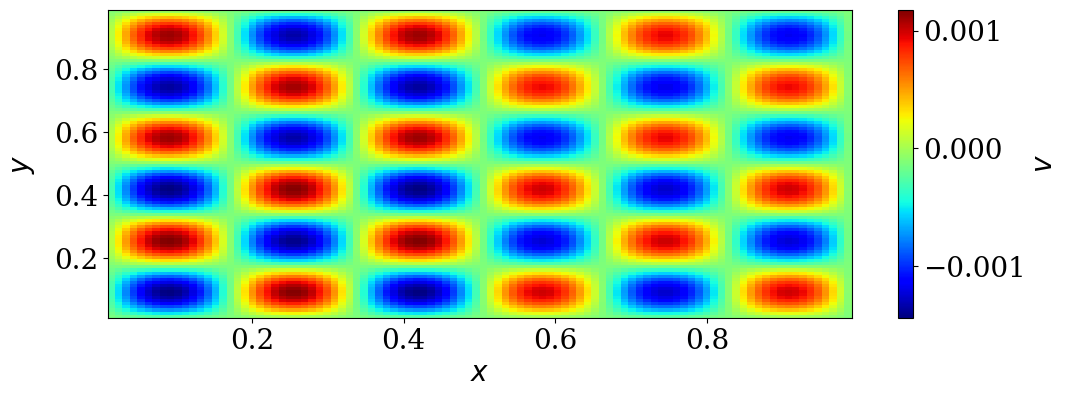

In [13]:
U = uv['res']["u"].reshape(fom.mesh.n['y'], fom.mesh.n['x'])
V = uv['res']["v"].reshape(fom.mesh.n['y'], fom.mesh.n['x'])
print(mu[0])
plot_field(
  z=U,
  label="$u$",
  filename="./u.png",
  **plot_kwargs
)
plot_field(
  z=V,
  label="$v$",
  filename="./v.png",
  **plot_kwargs
)

In [7]:
n_samples = inputs["data_gen"]["n_samples"]
mu = {"train": [], "test": []}
if (n_samples.get("train", 0) > 0):
    mu["train"] = field.construct_design_mat(n_samples["train"])
if (n_samples.get("test", 0) > 0):
    mu["test"] = field.construct_design_mat_test(
    n_samples=n_samples["test"], dmat_train=mu["train"], tol=1e-1
    )

ValueError: operands could not be broadcast together with shapes (100,6) (1,4) 

In [20]:
print(mu['train'])

[[1.46070042 1.32160468 0.76613966 0.62704391 4.         6.        ]
 [1.06849038 1.15058356 0.56670638 0.64879956 2.         4.        ]
 [1.00035362 0.61118728 0.54774234 0.15857599 4.         6.        ]
 [0.93333145 1.3098058  0.90013237 1.27660672 4.         6.        ]
 [0.51963663 0.75928081 0.67956084 0.91920502 4.         4.        ]
 [1.02458604 0.70435865 1.07099615 0.75076876 4.         4.        ]
 [1.11783234 1.12554688 1.32886305 1.33657758 2.         4.        ]
 [1.35362189 0.90617877 0.99518835 0.54774523 2.         6.        ]
 [0.68301575 1.493651   0.59820993 1.40884518 4.         4.        ]
 [1.03756779 0.55616934 1.09131055 0.60991211 4.         2.        ]
 [1.31829897 1.14296556 1.49190567 1.31657226 4.         4.        ]
 [1.2059223  0.92097844 1.19382808 0.90888422 4.         6.        ]
 [0.55612096 0.72807319 0.97056848 1.14252071 2.         4.        ]
 [1.12424089 0.54264556 0.72569101 0.14409567 4.         6.        ]
 [0.63131798 0.73866382 1.31919783

In [17]:
print(mu['test'])

[]
